# UAPOML — Week 2 Complete Solution

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42) 
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

#### 1a) Create prices DataFrame and compute daily percentage returns

**Concept:** Daily percentage return = (Price_today - Price_yesterday) / Price_yesterday × 100  

In [296]:
data = {
    'RELIANCE':    [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':        [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':    [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS':  [ 520,  535,  528,  540,  555,  548]
}
days = [f'Day {i}' for i in range (1, 7)]

prices_df = pd.DataFrame(data, index = days)
print(" -- Price DataFrame Rs.--")
print(prices_df)

daily_return = prices_df.pct_change() * 100
print("\n -- Daily Percentage Returns (%) --")
print(daily_return.round(4))

 -- Price DataFrame Rs.--
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548

 -- Daily Percentage Returns (%) --
       RELIANCE    INFY  HDFCBANK  TATAMOTORS
Day 1       NaN     NaN       NaN         NaN
Day 2    1.7857  1.3793   -1.2500      2.8846
Day 3   -0.7018 -0.6803    1.8987     -1.3084
Day 4    2.4735  2.0548    0.9317      2.2727
Day 5   -0.6897  1.3423   -0.6154      2.7778
Day 6    2.4306 -0.6623    1.5480     -1.2613


#### 1b) Units purchased and portfolio value

**Concept:** Equal weight (25% each) means we split ₹10,00,000 evenly → ₹2,50,000 per asset.  

=== Units Purchased on Day 1 ===
RELIANCE       89.2857
INFY          172.4138
HDFCBANK      156.2500
TATAMOTORS    480.7692
dtype: float64

=== Daily Portfolio Value (₹) ===
Day 1    1000000.00
Day 2    1011999.10
Day 3    1009811.36
Day 4    1029346.76
Day 5    1036658.36
Day 6    1041725.09
dtype: float64


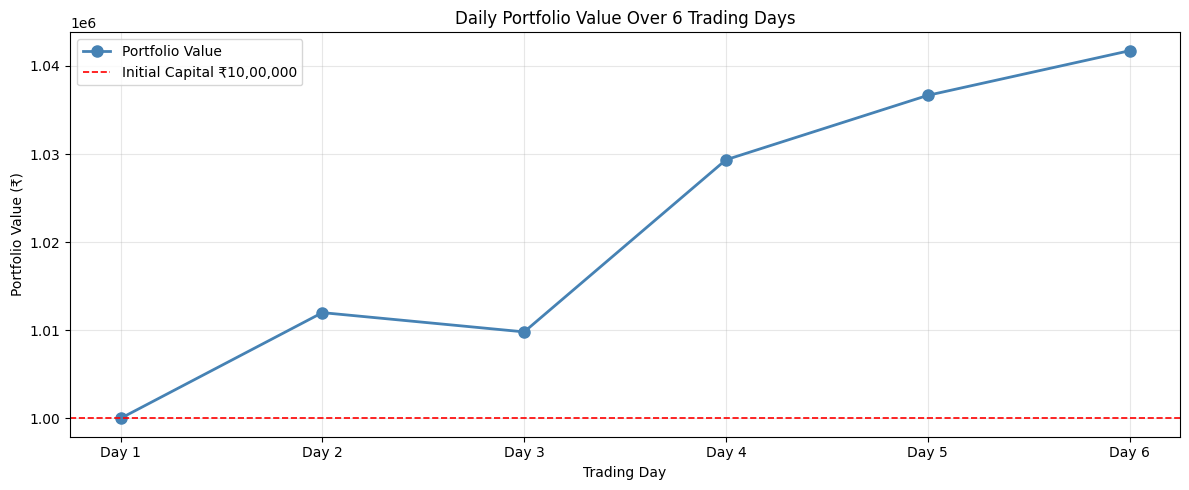

In [297]:
total_capital = 1_000_000  
weights = np.array([0.25, 0.25, 0.25, 0.25])

capital_per_asset = total_capital * weights          # ₹2,50,000 each
day1_prices = prices_df.iloc[0].values               # prices on Day 1

units = capital_per_asset / day1_prices
units_series = pd.Series(units, index=prices_df.columns)
print('=== Units Purchased on Day 1 ===')
print(units_series.round(4))

portfolio_value = prices_df.dot(units_series)
print('\n=== Daily Portfolio Value (₹) ===')
print(portfolio_value.round(2))

fig, ax = plt.subplots()
ax.plot(portfolio_value.index, portfolio_value.values, marker='o',
        color='steelblue', linewidth=2, markersize=8, label='Portfolio Value')
ax.axhline(total_capital, color='red', linestyle='--', linewidth=1.2,
           label='Initial Capital ₹10,00,000')
ax.set_title('Daily Portfolio Value Over 6 Trading Days')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend()
plt.tight_layout()
plt.show()

#### 1c) Annualised Volatility

**Concept:** Daily volatility (σ_daily) is the standard deviation of daily returns. Annualised volatility scales this up by √252 (there are 252 trading days in a year), assuming daily returns are i.i.d.

In [298]:

# Portfolio returns from the portfolio value series (skip NaN at Day 1)
portfolio_daily_returns = portfolio_value.pct_change().dropna()

sigma_daily   = portfolio_daily_returns.std()
sigma_annual  = sigma_daily * np.sqrt(252)

print(f'Daily Volatility   (σ_daily)  : {sigma_daily:.6f}  ({sigma_daily*100:.4f}%)')
print(f'Annualised Volatility (σ_ann) : {sigma_annual:.6f}  ({sigma_annual*100:.4f}%)')
print('\nInterpretation: The portfolio is expected to fluctuate by',
      f'{sigma_annual*100:.2f}% per year based on these 5 daily observations.')

Daily Volatility   (σ_daily)  : 0.008034  (0.8034%)
Annualised Volatility (σ_ann) : 0.127539  (12.7539%)

Interpretation: The portfolio is expected to fluctuate by 12.75% per year based on these 5 daily observations.


#### 2a) Value at Risk (VaR) at 95% and 99%

**Concept:** VaR at confidence level α answers: *"What is the minimum loss I can expect on my worst (1-α)% of days?"*  

In [299]:
np.random.seed(42)
n_sim = 50
sim_returns = np.random.normal(0.001, 0.015, n_sim)  # µ=0.001, σ=0.015

# Rebuild portfolio value from simulation
sim_portfolio = total_capital * np.cumprod(1 + sim_returns)

VaR_95 = -np.percentile(sim_returns, 5)   # 5th percentile → worst 5% days
VaR_99 = -np.percentile(sim_returns, 1)   # 1st percentile → worst 1% days

print('=== Value at Risk ===')
print(f'VaR 95% : {VaR_95*100:.4f}%  →  ₹{VaR_95*total_capital:,.0f}')
print(f'VaR 99% : {VaR_99*100:.4f}%  →  ₹{VaR_99*total_capital:,.0f}')
print('\nInterpretation:')
print(f'  VaR_95: On 95% of trading days, losses will NOT exceed ₹{VaR_95*total_capital:,.0f}.')
print(f'  VaR_99: On 99% of trading days, losses will NOT exceed ₹{VaR_99*total_capital:,.0f}.')

=== Value at Risk ===
VaR 95% : 2.5188%  →  ₹25,188
VaR 99% : 2.8054%  →  ₹28,054

Interpretation:
  VaR_95: On 95% of trading days, losses will NOT exceed ₹25,188.
  VaR_99: On 99% of trading days, losses will NOT exceed ₹28,054.


#### 2b) Conditional VaR (CVaR)

**Concept:** CVaR (also called Expected Shortfall) is the *average* loss given that the loss exceeds VaR.  
VaR only tells us a threshold; CVaR tells us *how bad* things get beyond that threshold.

In [300]:
CVaR_95 = -sim_returns[sim_returns < -VaR_95].mean()
CVaR_99 = -sim_returns[sim_returns < -VaR_99].mean()

print('Conditional VaR (Expected Shortfall)')
print(f'CVaR 95% : {CVaR_95*100:.4f}%  →  ₹{CVaR_95*total_capital:,.0f}')
print(f'CVaR 99% : {CVaR_99*100:.4f}%  →  ₹{CVaR_99*total_capital:,.0f}')
print('\nWhy CVaR > VaR? CVaR averages across the ENTIRE tail beyond VaR.')
print('VaR just gives the threshold; CVaR captures the severity of extreme losses.')

Conditional VaR (Expected Shortfall)
CVaR 95% : 2.7180%  →  ₹27,180
CVaR 99% : 2.8395%  →  ₹28,395

Why CVaR > VaR? CVaR averages across the ENTIRE tail beyond VaR.
VaR just gives the threshold; CVaR captures the severity of extreme losses.


#### 2c) Maximum Drawdown

**Concept:** Drawdown at time t = (Peak_so_far - Current_Value) / Peak_so_far  
Maximum Drawdown is the worst peak-to-trough decline, showing how much an investor would have lost at the worst possible entry and exit.

Maximum Drawdown : 18.1649%
Peak Value       : ₹1,079,386.27 at Day 10
Trough Value     : ₹883,317.08 at Day 50


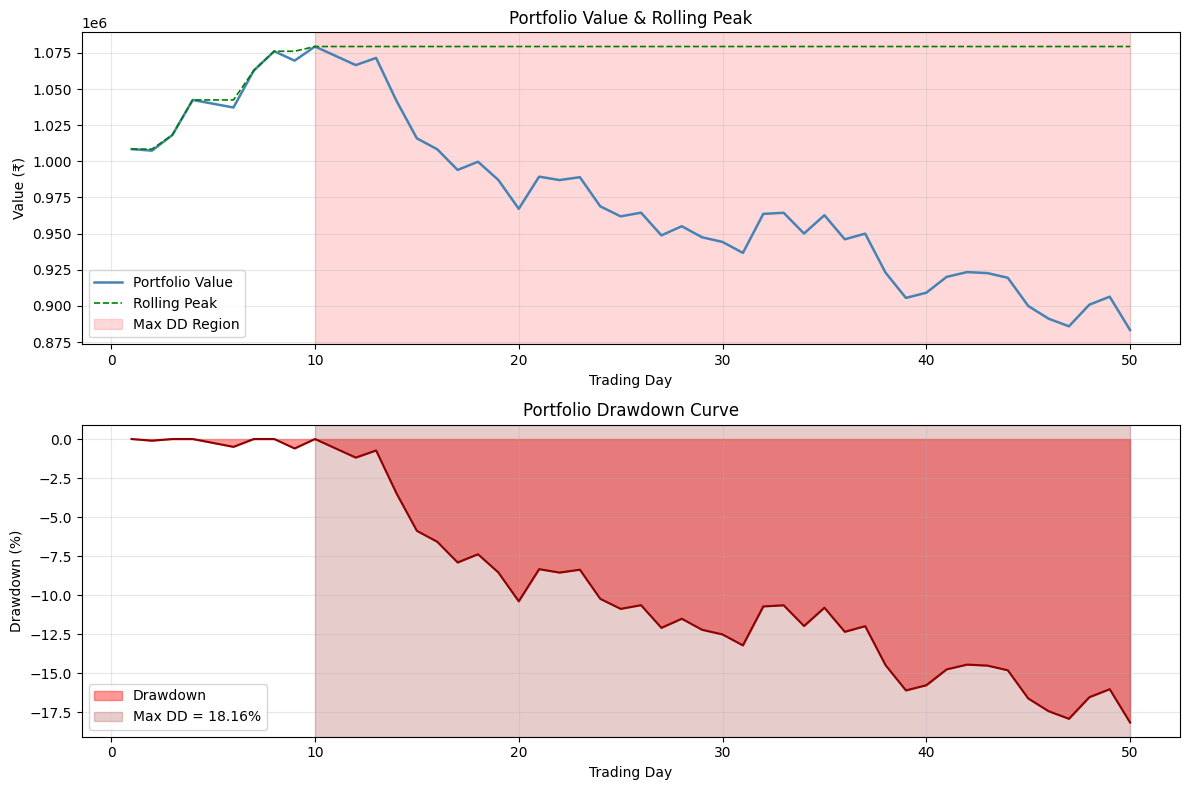

In [301]:
rolling_peak = np.maximum.accumulate(sim_portfolio)
drawdown = (rolling_peak - sim_portfolio) / rolling_peak  # fraction

max_dd = drawdown.max()
max_dd_idx = drawdown.argmax()

peak_idx = np.argmax(sim_portfolio[:max_dd_idx + 1])

print(f'Maximum Drawdown : {max_dd*100:.4f}%')
print(f'Peak Value       : ₹{sim_portfolio[peak_idx]:,.2f} at Day {peak_idx+1}')
print(f'Trough Value     : ₹{sim_portfolio[max_dd_idx]:,.2f} at Day {max_dd_idx+1}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(range(1, n_sim+1), sim_portfolio, color='steelblue', linewidth=1.8, label='Portfolio Value')
ax1.plot(range(1, n_sim+1), rolling_peak, 'g--', linewidth=1.2, label='Rolling Peak')
ax1.axvspan(peak_idx+1, max_dd_idx+1, alpha=0.15, color='red', label='Max DD Region')
ax1.set_title('Portfolio Value & Rolling Peak')
ax1.set_xlabel('Trading Day')
ax1.set_ylabel('Value (₹)')
ax1.legend()

ax2.fill_between(range(1, n_sim+1), -drawdown * 100, 0,
                 alpha=0.4, color='red', label='Drawdown')
ax2.axvspan(peak_idx+1, max_dd_idx+1, alpha=0.2, color='darkred', label=f'Max DD = {max_dd*100:.2f}%')
ax2.plot(range(1, n_sim+1), -drawdown * 100, color='darkred', linewidth=1.5)
ax2.set_title('Portfolio Drawdown Curve')
ax2.set_xlabel('Trading Day')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()

plt.tight_layout()
plt.show()

#### 3a) Sharpe Ratio

**Concept:** Sharpe Ratio = Excess Return / Total Risk  
It measures how much return you earn per unit of total volatility. Higher = better.  
Rule of thumb: Sharpe > 1 is good, > 2 is very good, > 3 is exceptional.

In [302]:
np.random.seed(42)
n_days = 252
port_returns_252 = np.random.normal(0.001, 0.015, n_days)

Rf_annual = 0.06                    # 6% p.a. risk-free rate
Rf_daily  = Rf_annual / 252         # daily risk-free rate

Rp_daily   = port_returns_252.mean()
Rp_annual  = Rp_daily * 252
sig_daily  = port_returns_252.std()
sig_annual = sig_daily * np.sqrt(252)

sharpe = (Rp_annual - Rf_annual) / sig_annual

print(f'Annualised Return       : {Rp_annual*100:.4f}%')
print(f'Annualised Volatility   : {sig_annual*100:.4f}%')
print(f'Risk-Free Rate          : {Rf_annual*100:.2f}%')
print(f'Sharpe Ratio            : {sharpe:.4f}')

Annualised Return       : 23.7769%
Annualised Volatility   : 22.9854%
Risk-Free Rate          : 6.00%
Sharpe Ratio            : 0.7734


#### 3b) Sortino Ratio

**Concept:** Sortino uses only *downside* deviation (negative returns only) as the risk measure.  

In [303]:
negative_returns = port_returns_252[port_returns_252 < 0]
sigma_down_daily  = negative_returns.std()          # downside deviation
sigma_down_annual = sigma_down_daily * np.sqrt(252)

sortino = (Rp_annual - Rf_annual) / sigma_down_annual

print(f'Downside Volatility (ann.) : {sigma_down_annual*100:.4f}%')
print(f'Sortino Ratio              : {sortino:.4f}')
print(f'\nSortino > Sharpe: {sortino > sharpe}')

Downside Volatility (ann.) : 12.5596%
Sortino Ratio              : 1.4154

Sortino > Sharpe: True


#### 3c) Comparison DataFrame

In [304]:

comparison = pd.DataFrame({
    'Metric':       ['Annualised Return', 'Volatility Used', 'Risk-Free Rate', 'Ratio Value'],
    'Sharpe Ratio': [f'{Rp_annual*100:.4f}%', f'{sig_annual*100:.4f}% (Total)',
                     f'{Rf_annual*100:.2f}%', f'{sharpe:.4f}'],
    'Sortino Ratio':[f'{Rp_annual*100:.4f}%', f'{sigma_down_annual*100:.4f}% (Downside)',
                     f'{Rf_annual*100:.2f}%', f'{sortino:.4f}']
})
print(comparison.to_string(index=False))
print('\nConclusion: For asymmetrically returning strategies (like momentum or trend-following')
print('that can have large positive outliers), Sortino is more appropriate.')
print('As it sharpe penalises upward volatility equally, which may underestimate strategy quality.')

           Metric     Sharpe Ratio       Sortino Ratio
Annualised Return         23.7769%            23.7769%
  Volatility Used 22.9854% (Total) 12.5596% (Downside)
   Risk-Free Rate            6.00%               6.00%
      Ratio Value           0.7734              1.4154

Conclusion: For asymmetrically returning strategies (like momentum or trend-following
that can have large positive outliers), Sortino is more appropriate.
As it sharpe penalises upward volatility equally, which may underestimate strategy quality.


#### 4a) SMA Crossover Signal

**Concept:** A 10/30 SMA crossover is a classic trend-following signal.  
- When the fast MA (10) crosses above the slow MA (30) → uptrend is starting → **Buy (+1)**  
- When fast crosses below slow → downtrend → **Sell/Short (−1)**  


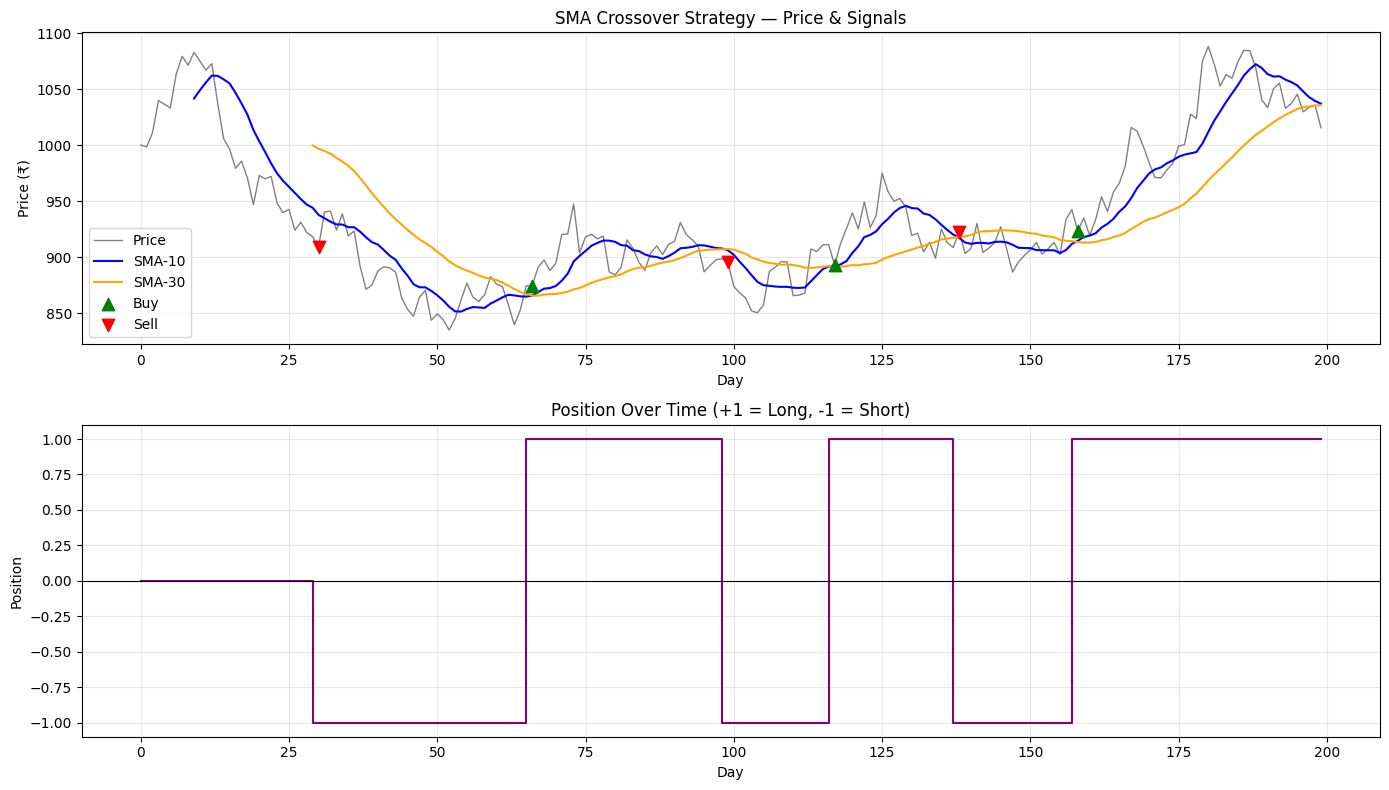

In [305]:

np.random.seed(42)
n_bt = 200
eps = np.random.normal(0.001, 0.018, n_bt)
P = np.zeros(n_bt)
P[0] = 1000
for t in range(1, n_bt):
    P[t] = P[t-1] * (1 + eps[t])

price_series = pd.Series(P)


sma10 = price_series.rolling(10).mean()
sma30 = price_series.rolling(30).mean()

# Raw position: +1 when sma10 > sma30, -1 otherwise
raw_position = np.where(sma10 > sma30, 1, -1)
raw_position[:30] = 0  # no signal until sma30 is valid

position = pd.Series(raw_position, dtype=float)

signal = position.diff()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.plot(price_series, color='gray', linewidth=1, label='Price')
ax1.plot(sma10, color='blue', linewidth=1.5, label='SMA-10')
ax1.plot(sma30, color='orange', linewidth=1.5, label='SMA-30')

buy_signals  = price_series[signal > 0]
sell_signals = price_series[signal < 0]
ax1.scatter(buy_signals.index,  buy_signals.values,  marker='^', color='green', s=80, zorder=5, label='Buy')
ax1.scatter(sell_signals.index, sell_signals.values, marker='v', color='red',   s=80, zorder=5, label='Sell')
ax1.set_title('SMA Crossover Strategy — Price & Signals')
ax1.set_xlabel('Day')
ax1.set_ylabel('Price (₹)')
ax1.legend()

ax2.step(position.index, position.values, color='purple', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Position Over Time (+1 = Long, -1 = Short)')
ax2.set_xlabel('Day')
ax2.set_ylabel('Position')
plt.tight_layout()
plt.show()

#### 4b) Strategy vs Buy-and-Hold Cumulative Return

Strategy Cumulative Return   : 18.94%
Buy-and-Hold Cumulative Return: 1.55%


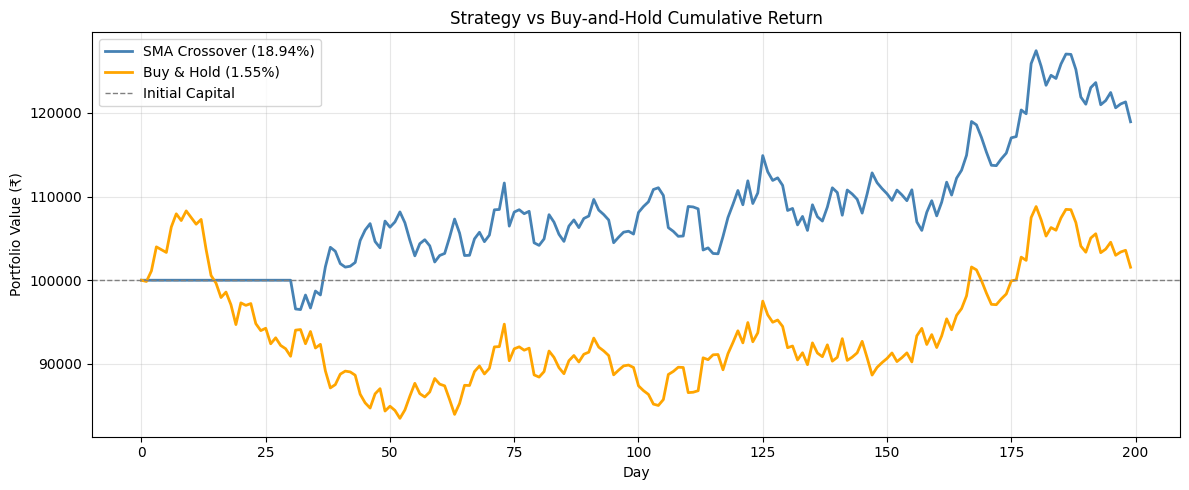

In [306]:
asset_returns = price_series.pct_change().fillna(0)
strategy_returns = position.shift(1).fillna(0) * asset_returns

initial_capital = 100_000
strategy_cum    = initial_capital * (1 + strategy_returns).cumprod()
bh_cum          = initial_capital * (1 + asset_returns).cumprod()

strat_ret_pct = (strategy_cum.iloc[-1] / initial_capital - 1) * 100
bh_ret_pct    = (bh_cum.iloc[-1]    / initial_capital - 1) * 100

print(f'Strategy Cumulative Return   : {strat_ret_pct:.2f}%')
print(f'Buy-and-Hold Cumulative Return: {bh_ret_pct:.2f}%')

fig, ax = plt.subplots()
ax.plot(strategy_cum, color='steelblue', linewidth=2, label=f'SMA Crossover ({strat_ret_pct:.2f}%)')
ax.plot(bh_cum,       color='orange',    linewidth=2, label=f'Buy & Hold ({bh_ret_pct:.2f}%)')
ax.axhline(initial_capital, color='gray', linestyle='--', linewidth=1, label='Initial Capital')
ax.set_title('Strategy vs Buy-and-Hold Cumulative Return')
ax.set_xlabel('Day')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend()
plt.tight_layout()
plt.show()

#### 4c) Win Rate & Profit Factor

In [307]:
trade_returns = strategy_returns[strategy_returns != 0]

winning_trades = trade_returns[trade_returns > 0]
losing_trades  = trade_returns[trade_returns < 0]

win_rate = len(winning_trades) / len(trade_returns) if len(trade_returns) > 0 else 0
profit_factor = winning_trades.sum() / abs(losing_trades.sum()) if len(losing_trades) > 0 else np.inf

print(f'Total Trading Days with Position : {len(trade_returns)}')
print(f'Winning Days                     : {len(winning_trades)}')
print(f'Losing Days                      : {len(losing_trades)}')
print(f'Win Rate                         : {win_rate*100:.2f}%')
print(f'Profit Factor                    : {profit_factor:.4f}')
print()
print('Does PF > 1 guarantee a good strategy? NO.')
print('Reasons:')
print('  Transaction costs (brokerage, slippage) can eliminate profitability.')
print('  A strategy can be profitable historically but fail out-of-sample (overfitting).')
print('  A single catastrophic loss can wipe out years of small gains (tail risk).')

Total Trading Days with Position : 169
Winning Days                     : 88
Losing Days                      : 81
Win Rate                         : 52.07%
Profit Factor                    : 1.1907

Does PF > 1 guarantee a good strategy? NO.
Reasons:
  Transaction costs (brokerage, slippage) can eliminate profitability.
  A strategy can be profitable historically but fail out-of-sample (overfitting).
  A single catastrophic loss can wipe out years of small gains (tail risk).


#### 5a) Engineer Features

**Concept:**  
- **Return_1d**: how much did the price move yesterday? (momentum signal)  
- **SMA_5/20**: where is the price relative to its recent averages?  
- **Volatility_10**: how choppy has the market been recently?  
- **Momentum_5**: absolute price change over 5 days (trend strength)

In [308]:
np.random.seed(42)
n_feat = 300
eps5 = np.random.normal(0.001, 0.018, n_feat)
P5 = np.zeros(n_feat)
P5[0] = 500
for t in range(1, n_feat):
    P5[t] = P5[t-1] * (1 + eps5[t])
price5 = pd.Series(P5, name='Price')

feat_df = pd.DataFrame()
feat_df['Price']       = price5
feat_df['Return_1d']   = price5.pct_change()                   # 1-day return
feat_df['SMA_5']       = price5.rolling(5).mean()              # 5-day SMA
feat_df['SMA_20']      = price5.rolling(20).mean()             # 20-day SMA
feat_df['Volatility_10'] = feat_df['Return_1d'].rolling(10).std()  # 10-day vol
feat_df['Momentum_5']  = price5 - price5.shift(5)              # 5-day momentum

feat_df = feat_df.dropna().reset_index(drop=True)
print(f'Shape after dropping NaN: {feat_df.shape}')
print(feat_df.head(5).round(4))

Shape after dropping NaN: (281, 6)
      Price  Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5
0  473.5021    -0.0244  487.9360  513.8214         0.0136    -29.3289
1  486.4674     0.0274  485.5806  513.1448         0.0187    -11.7772
2  484.9769    -0.0031  484.6441  512.4309         0.0188     -4.6825
3  486.0514     0.0022  483.2706  511.4547         0.0186     -6.8674
4  474.0724    -0.0246  481.0140  509.1612         0.0175    -11.2828


#### 5b) Binary Target Variable

**Concept:** We predict *tomorrow's direction* — a binary classification task.  y = 1 if next day's return > 0, else 0. This is a common formulation for ML in trading.

Class Distribution:
Target
1    151
0    129
Name: count, dtype: int64

Class Balance — Up (1): 53.93%  |  Down (0): 46.07%


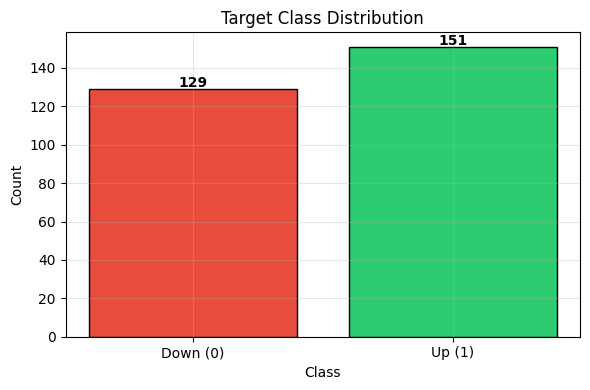

In [309]:
feat_df['Next_Return'] = feat_df['Return_1d'].shift(-1)
feat_df['Target']      = (feat_df['Next_Return'] > 0).astype(int)
feat_df = feat_df.dropna().reset_index(drop=True)

class_counts = feat_df['Target'].value_counts()
print('Class Distribution:')
print(class_counts)
print(f'\nClass Balance — Up (1): {class_counts[1]/len(feat_df)*100:.2f}%  |  Down (0): {class_counts[0]/len(feat_df)*100:.2f}%')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Down (0)', 'Up (1)'], [class_counts.get(0,0), class_counts.get(1,0)],
       color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for i, v in enumerate([class_counts.get(0,0), class_counts.get(1,0)]):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### 5c) Min-Max Normalisation



In [310]:
feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X_raw = feat_df[feature_cols].values
y     = feat_df['Target'].values

X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

print('Feature ranges after scaling:')
for i, col in enumerate(feature_cols):
    print(f'  {col:15s}: min={X_scaled[:,i].min():.4f}, max={X_scaled[:,i].max():.4f}')
print('All features now in [0, 1] ✓')

Feature ranges after scaling:
  Return_1d      : min=0.0000, max=1.0000
  SMA_5          : min=0.0000, max=1.0000
  SMA_20         : min=0.0000, max=1.0000
  Volatility_10  : min=0.0000, max=1.0000
  Momentum_5     : min=0.0000, max=1.0000
All features now in [0, 1] ✓


#### 6a) KNN Implementation

In [311]:

def euclidean_distance(x1, x2):
    """Compute Euclidean distance between two 1D arrays."""
    return np.sqrt(np.sum((x1 - x2) ** 2))

def knn_predict(X_train, y_train, X_test, k):
    """
    KNN prediction for all test points.
    Returns array of predicted labels (0 or 1).
    """
    predictions = []
    for test_point in X_test:
        # Step 1: distance from test_point to every training point
        distances = np.array([euclidean_distance(test_point, x_tr) for x_tr in X_train])
        # Step 2: indices of k nearest neighbours (ascending order)
        k_nearest_idx = np.argsort(distances)[:k]
        # Step 3: majority vote
        k_labels = y_train[k_nearest_idx]
        majority_vote = int(np.round(k_labels.mean()))  # round mean = majority vote for binary
        predictions.append(majority_vote)
    return np.array(predictions)

print('KNN functions defined: euclidean_distance(), knn_predict() ✓')

KNN functions defined: euclidean_distance(), knn_predict() ✓


#### 6b) Accuracy for Different k Values

Training KNN for each k value...
  k= 3 → Accuracy: 58.93%
  k= 5 → Accuracy: 51.79%
  k= 7 → Accuracy: 55.36%
  k=11 → Accuracy: 44.64%
  k=15 → Accuracy: 60.71%

Optimal k = 15 with accuracy 60.71%


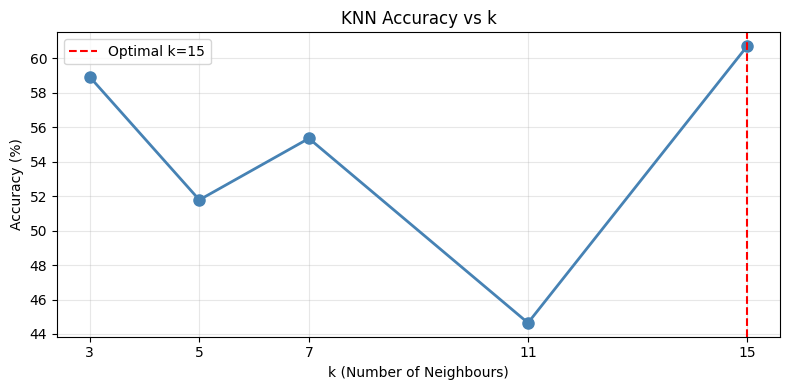

In [312]:

split = int(0.8 * len(X_scaled))
X_train_knn, X_test_knn = X_scaled[:split], X_scaled[split:]
y_train_knn, y_test_knn = y[:split], y[split:]

k_values = [3, 5, 7, 11, 15]
accuracies = {}

print('Training KNN for each k value...')
for k in k_values:
    preds = knn_predict(X_train_knn, y_train_knn, X_test_knn, k)
    acc   = (preds == y_test_knn).mean()
    accuracies[k] = acc
    print(f'  k={k:2d} → Accuracy: {acc*100:.2f}%')

best_k = max(accuracies, key=accuracies.get)
print(f'\nOptimal k = {best_k} with accuracy {accuracies[best_k]*100:.2f}%')


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, [accuracies[k]*100 for k in k_values],
        marker='o', color='steelblue', linewidth=2, markersize=8)
ax.axvline(best_k, color='red', linestyle='--', label=f'Optimal k={best_k}')
ax.set_title('KNN Accuracy vs k')
ax.set_xlabel('k (Number of Neighbours)')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.show()

#### 6c) Confusion Matrix — Precision & Recall

In [313]:

best_preds = knn_predict(X_train_knn, y_train_knn, X_test_knn, best_k)

TP = ((best_preds == 1) & (y_test_knn == 1)).sum()
TN = ((best_preds == 0) & (y_test_knn == 0)).sum()
FP = ((best_preds == 1) & (y_test_knn == 0)).sum()
FN = ((best_preds == 0) & (y_test_knn == 1)).sum()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

conf_matrix = pd.DataFrame([[TP, FP], [FN, TN]],
                           index=['Predicted Up', 'Predicted Down'],
                           columns=['Actual Up', 'Actual Down'])
print(f'Confusion Matrix (k={best_k}):')
print(conf_matrix)
print(f'\nPrecision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print()

Confusion Matrix (k=15):
                Actual Up  Actual Down
Predicted Up           21           15
Predicted Down          7           13

Precision : 0.5833
Recall    : 0.7500
F1 Score  : 0.6562



#### 7a) Normal Equation

In [314]:

y_reg = feat_df['Next_Return'].values  
X_bias = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])  # shape: (n, 6)

split_r = int(0.8 * len(X_bias))
X_tr, X_te = X_bias[:split_r], X_bias[split_r:]
y_tr, y_te = y_reg[:split_r], y_reg[split_r:]

beta = np.linalg.inv(X_tr.T @ X_tr) @ X_tr.T @ y_tr

coef_names = ['Intercept'] + feature_cols
print('=== Learned Coefficients (Normal Equation) ===')
for name, coef in zip(coef_names, beta):
    direction = '+ve (positive relationship)' if coef > 0 else '-ve (negative relationship)'
    print(f'  {name:15s}: {coef:+.8f}  → {direction}')

=== Learned Coefficients (Normal Equation) ===
  Intercept      : +0.01129612  → +ve (positive relationship)
  Return_1d      : -0.00558107  → -ve (negative relationship)
  SMA_5          : +0.01942073  → +ve (positive relationship)
  SMA_20         : -0.01737338  → -ve (negative relationship)
  Volatility_10  : -0.00380291  → -ve (negative relationship)
  Momentum_5     : -0.01406484  → -ve (negative relationship)


#### 7b) Predictions — MSE and R²

MSE : 0.00035281
R²  : 0.027316

Note: Low R² is expected in finance — returns are nearly unpredictable.


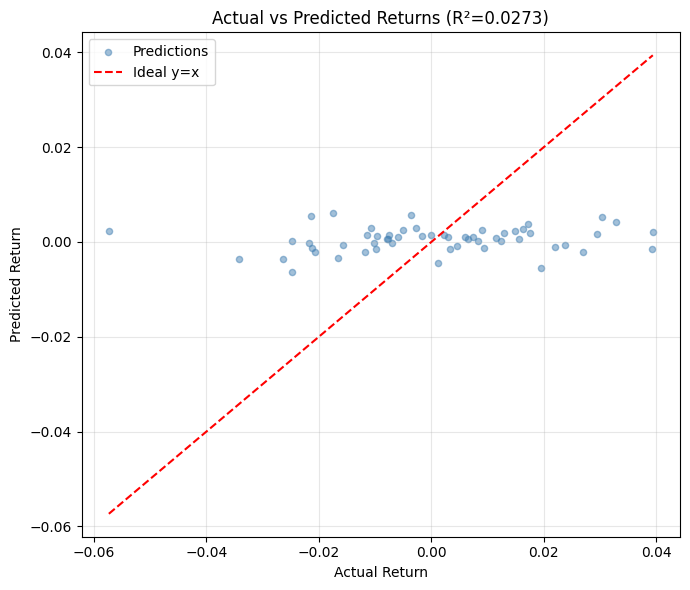

In [315]:
y_pred = X_te @ beta

MSE = np.mean((y_te - y_pred) ** 2)
SS_res = np.sum((y_te - y_pred) ** 2)
SS_tot = np.sum((y_te - y_te.mean()) ** 2)
R2 = 1 - SS_res / SS_tot

print(f'MSE : {MSE:.8f}')
print(f'R²  : {R2:.6f}')
print()
print('Note: Low R² is expected in finance — returns are nearly unpredictable.')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_te, y_pred, alpha=0.5, color='steelblue', s=20, label='Predictions')
min_val, max_val = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Ideal y=x')
ax.set_title(f'Actual vs Predicted Returns (R²={R2:.4f})')
ax.set_xlabel('Actual Return')
ax.set_ylabel('Predicted Return')
ax.legend()
plt.tight_layout()
plt.show()

#### 7c) Gradient Descent Implementation

=== Gradient Descent vs Normal Equation Comparison ===
Feature              Normal Eq   Grad Descent     Difference
Intercept           0.01129612     0.00195909       9.34e-03
Return_1d          -0.00558107    -0.00087140       4.71e-03
SMA_5               0.01942073     0.00036072       1.91e-02
SMA_20             -0.01737338     0.00018396       1.76e-02
Volatility_10      -0.00380291    -0.00038224       3.42e-03
Momentum_5         -0.01406484    -0.00087460       1.32e-02


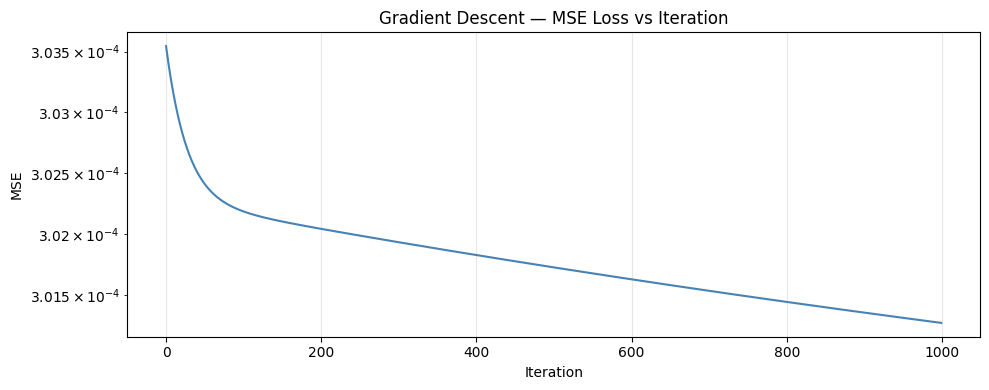


Conclusion: GD coefficients converge close to Normal Equation solution.
Differences are due to finite iterations and floating-point precision.


In [316]:
eta   = 0.01    # learning rate
n_iter = 1000
n_tr   = len(X_tr)

beta_gd = np.zeros(X_tr.shape[1]) 
loss_history = []

for iteration in range(n_iter):
    residuals = X_tr @ beta_gd - y_tr              # predictions - actual
    gradient  = (X_tr.T @ residuals) / n_tr        # gradient of MSE w.r.t. β
    beta_gd   = beta_gd - eta * gradient           # update step
    mse_iter  = np.mean(residuals ** 2)             # record loss
    loss_history.append(mse_iter)

print('=== Gradient Descent vs Normal Equation Comparison ===')
print(f'{"Feature":<15} {"Normal Eq":>14} {"Grad Descent":>14} {"Difference":>14}')
for name, b_ne, b_gd in zip(coef_names, beta, beta_gd):
    print(f'{name:<15} {b_ne:>14.8f} {b_gd:>14.8f} {abs(b_ne-b_gd):>14.2e}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history, color='steelblue', linewidth=1.5)
ax.set_title('Gradient Descent — MSE Loss vs Iteration')
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE')
ax.set_yscale('log')
plt.tight_layout()
plt.show()
print('\nConclusion: GD coefficients converge close to Normal Equation solution.')
print('Differences are due to finite iterations and floating-point precision.')

#### 8a) Predict Expected Returns for All 4 Assets

In [317]:

def build_features_and_target(price_array, n_steps=300):
    """Returns (X_scaled, y_reg, feat_df) for a given price series."""
    ps = pd.Series(price_array[:n_steps])
    df = pd.DataFrame()
    df['Return_1d']    = ps.pct_change()
    df['SMA_5']        = ps.rolling(5).mean()
    df['SMA_20']       = ps.rolling(20).mean()
    df['Volatility_10']= df['Return_1d'].rolling(10).std()
    df['Momentum_5']   = ps - ps.shift(5)
    df['Next_Return']  = df['Return_1d'].shift(-1)
    df = df.dropna().reset_index(drop=True)

    X = df[['Return_1d','SMA_5','SMA_20','Volatility_10','Momentum_5']].values
    y = df['Next_Return'].values
    Xmin, Xmax = X.min(0), X.max(0)
    Xs = (X - Xmin) / (Xmax - Xmin + 1e-10)
    return Xs, y

def fit_ols(Xs, y, train_frac=0.8):
    """Fit OLS via Normal Equation; return beta and test-set predictions."""
    n = len(Xs)
    sp = int(train_frac * n)
    Xb = np.hstack([np.ones((n,1)), Xs])
    X_tr, X_te = Xb[:sp], Xb[sp:]
    y_tr, y_te = y[:sp], y[sp:]
    beta = np.linalg.inv(X_tr.T @ X_tr + 1e-10*np.eye(X_tr.shape[1])) @ X_tr.T @ y_tr
    mu_hat = (X_te @ beta).mean()  # mean predicted return on test period
    return beta, mu_hat, X_te @ beta, y_te

np.random.seed(42)
asset_params = {
    'RELIANCE':   (0.0008, 0.016, 2800),
    'INFY':       (0.0010, 0.018, 1450),
    'HDFCBANK':   (0.0005, 0.014, 1600),
    'TATAMOTORS': (0.0012, 0.022,  520),
}

mu_hats = {}
test_pred_returns = {}
test_actual_returns = {}

for asset, (mu, sig, p0) in asset_params.items():
    eps_a = np.random.normal(mu, sig, 300)
    Pa = np.zeros(300); Pa[0] = p0
    for t in range(1, 300): Pa[t] = Pa[t-1] * (1 + eps_a[t])

    Xs_a, y_a = build_features_and_target(Pa)
    _, mu_hat, preds, actuals = fit_ols(Xs_a, y_a)
    mu_hats[asset] = mu_hat
    test_pred_returns[asset] = preds
    test_actual_returns[asset] = actuals

print('=== Predicted Average Daily Returns (Test Period) ===')
for a, m in mu_hats.items():
    print(f'  {a:<15}: {m*100:+.6f}%')

=== Predicted Average Daily Returns (Test Period) ===
  RELIANCE       : +0.020332%
  INFY           : +0.493948%
  HDFCBANK       : -0.458622%
  TATAMOTORS     : +0.835158%


#### 8b) ML-Driven Portfolio Weights

In [318]:
# ── 8b Weight Allocation ──────────────────────────────────────────────────────
mu_array = np.array(list(mu_hats.values()))
positive_mu = np.maximum(mu_array, 0)         # only allocate to positive forecasts

if positive_mu.sum() > 0:
    weights_ml = positive_mu / positive_mu.sum()
else:
    weights_ml = np.ones(4) / 4               # fallback to equal weight

print('=== ML-Driven Portfolio Weights ===')
for a, w in zip(asset_params.keys(), weights_ml):
    print(f'  {a:<15}: {w*100:.2f}%')
print(f'\nSum of weights: {weights_ml.sum():.6f} ')

=== ML-Driven Portfolio Weights ===
  RELIANCE       : 1.51%
  INFY           : 36.60%
  HDFCBANK       : 0.00%
  TATAMOTORS     : 61.89%

Sum of weights: 1.000000 


#### 8c) ML-Driven vs Equal-Weight Backtest

ML-Driven Portfolio Cumulative Return  : -0.6893%
Equal-Weight Portfolio Cumulative Return: 8.2688%


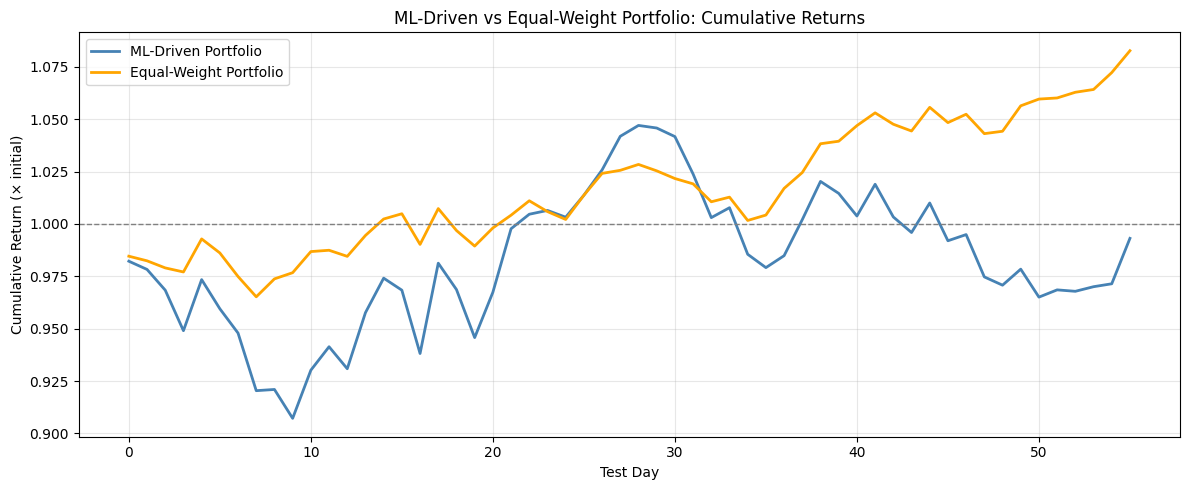


Limitation of this approach:
Linear Regression predicts returns from past features, but financial returns
are largely unpredictable (efficient market hypothesis). The model may overfit
in-sample patterns that do not hold out-of-sample. Additionally, this approach
ignores asset covariance — a portfolio with better Sharpe could be constructed.


In [319]:

assets = list(asset_params.keys())
min_len = min(len(test_actual_returns[a]) for a in assets)
actual_mat = np.array([test_actual_returns[a][:min_len] for a in assets]).T  # (T, 4)

ml_daily_ret = actual_mat @ weights_ml
eq_daily_ret = actual_mat @ np.array([0.25, 0.25, 0.25, 0.25])

ml_cum = (1 + ml_daily_ret).cumprod()
eq_cum = (1 + eq_daily_ret).cumprod()

print(f'ML-Driven Portfolio Cumulative Return  : {(ml_cum[-1]-1)*100:.4f}%')
print(f'Equal-Weight Portfolio Cumulative Return: {(eq_cum[-1]-1)*100:.4f}%')

fig, ax = plt.subplots()
ax.plot(ml_cum, color='steelblue', linewidth=2, label='ML-Driven Portfolio')
ax.plot(eq_cum, color='orange',    linewidth=2, label='Equal-Weight Portfolio')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_title('ML-Driven vs Equal-Weight Portfolio: Cumulative Returns')
ax.set_xlabel('Test Day')
ax.set_ylabel('Cumulative Return (× initial)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nLimitation of this approach:')
print('Linear Regression predicts returns from past features, but financial returns')
print('are largely unpredictable (efficient market hypothesis). The model may overfit')
print('in-sample patterns that do not hold out-of-sample. Additionally, this approach')
print('ignores asset covariance — a portfolio with better Sharpe could be constructed.')

#### 9a) k-Fold Cross Validation for KNN (from Scratch)

In [320]:
def kfold_cv_knn(X, y, k_cv=5, k_knn=5):
    """
    k-Fold Cross Validation for KNN.
    Returns list of accuracy scores for each fold.
    """
    n = len(X)
    fold_size = n // k_cv
    indices = np.arange(n)
    scores = []

    for fold in range(k_cv):
        # Validation fold indices
        val_start = fold * fold_size
        val_end   = val_start + fold_size if fold < k_cv - 1 else n
        val_idx   = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])

        X_tr_cv, y_tr_cv = X[train_idx], y[train_idx]
        X_va_cv, y_va_cv = X[val_idx],   y[val_idx]

        preds = knn_predict(X_tr_cv, y_tr_cv, X_va_cv, k_knn)
        acc   = (preds == y_va_cv).mean()
        scores.append(acc)

    return scores

k_knn_values = [3, 7, 11]
cv_results = {}

print('Running 5-Fold CV for KNN (this may take a moment)...')
for k_knn in k_knn_values:
    scores = kfold_cv_knn(X_scaled, y, k_cv=5, k_knn=k_knn)
    cv_results[k_knn] = scores
    print(f'  k={k_knn:2d}: Mean Acc = {np.mean(scores)*100:.2f}%  |  Std = {np.std(scores)*100:.2f}%  |  Folds: {[f"{s*100:.1f}%" for s in scores]}')

Running 5-Fold CV for KNN (this may take a moment)...


  k= 3: Mean Acc = 48.21%  |  Std = 10.41%  |  Folds: ['35.7%', '48.2%', '37.5%', '60.7%', '58.9%']
  k= 7: Mean Acc = 50.00%  |  Std = 6.59%  |  Folds: ['41.1%', '50.0%', '44.6%', '58.9%', '55.4%']
  k=11: Mean Acc = 51.43%  |  Std = 8.78%  |  Folds: ['41.1%', '55.4%', '50.0%', '66.1%', '44.6%']


#### 9b) Performance Summary DataFrame

In [321]:
# ── 9b Performance Comparison Table ───────────────────────────────────────────
# Best KNN results
best_cv_k = max(cv_results, key=lambda k: np.mean(cv_results[k]))
best_cv_acc = np.mean(cv_results[best_cv_k])

# Linear Regression test metrics (from Problem 7)
y_pred_final = X_te @ beta
mse_lr = np.mean((y_te - y_pred_final)**2)
ss_res = np.sum((y_te - y_pred_final)**2)
ss_tot = np.sum((y_te - y_te.mean())**2)
r2_lr  = 1 - ss_res / ss_tot

summary = pd.DataFrame([
    {
        'Model':       'KNN Classifier',
        'Accuracy/R²': f'{best_cv_acc*100:.2f}%',
        'MSE/N.A.':    'N/A (classification)',
        'Best Param':  f'k={best_cv_k} (5-fold CV)'
    },
    {
        'Model':       'Linear Regression',
        'Accuracy/R²': f'{r2_lr:.6f}',
        'MSE/N.A.':    f'{mse_lr:.8f}',
        'Best Param':  'Normal Equation'
    }
])
print('=== Model Performance Summary ===')
print(summary.to_string(index=False))

=== Model Performance Summary ===
            Model Accuracy/R²             MSE/N.A.       Best Param
   KNN Classifier      51.43% N/A (classification) k=11 (5-fold CV)
Linear Regression    0.027316           0.00035281  Normal Equation


#### 9c) Model Deployment Decision & Risks

In [322]:

print('Which model to deploy in a real trading system?')
print('-'*60)
print()
print('RECOMMENDATION: KNN Classifier (for direction prediction)')
print()
print('Reasoning:')
print('  - Classification (Up/Down) is more actionable than return prediction.')
print('  - Linear Regression assumes a linear relationship between features and returns — rarely true in financial markets.')
print('  - KNN is non-parametric and can capture local non-linearities.')
print('  - However, with more features and proper tuning, tree-based models')
print('    (XGBoost, Random Forest) typically outperform both.')
print()
print('TWO RISKS OF DEPLOYING AN ML MODEL IN LIVE TRADING:')
print()
print('1. OVERFITTING / LOOK-AHEAD BIAS:')
print('   Models trained on historical data may exploit spurious patterns.')
print('   Look-ahead bias occurs if features inadvertently include future data e.g., using next-day VWAP as a feature. Validate using Walk-Forward')
print('   Analysis — retrain model only on past data at each rebalance point.')
print()
print('2. REGIME CHANGE / NON-STATIONARITY:')
print('   Financial markets change regime (bull→bear, crisis, policy change).')
print('   A model trained on 2019-2021 data will fail in a 2022-style rate hike cycle.')
print('   Mitigation: use rolling retraining windows and monitor model degradation with live performance tracking and automatic circuit breakers.')

Which model to deploy in a real trading system?
------------------------------------------------------------

RECOMMENDATION: KNN Classifier (for direction prediction)

Reasoning:
  - Classification (Up/Down) is more actionable than return prediction.
  - Linear Regression assumes a linear relationship between features and returns — rarely true in financial markets.
  - KNN is non-parametric and can capture local non-linearities.
  - However, with more features and proper tuning, tree-based models
    (XGBoost, Random Forest) typically outperform both.

TWO RISKS OF DEPLOYING AN ML MODEL IN LIVE TRADING:

1. OVERFITTING / LOOK-AHEAD BIAS:
   Models trained on historical data may exploit spurious patterns.
   Look-ahead bias occurs if features inadvertently include future data e.g., using next-day VWAP as a feature. Validate using Walk-Forward
   Analysis — retrain model only on past data at each rebalance point.

2. REGIME CHANGE / NON-STATIONARITY:
   Financial markets change regime (